In [1]:
#Cargamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix , ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


In [ ]:
#Carga del DataSet y visualizacion de los primeros datos
vinos = pd.read_csv('/content/winequality-red.csv', sep=';')
vinos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
#REGRESION LOGISTICA

x = vinos[["fixed acidity","volatile acidity","citric acid","residual sugar",
           "chlorides","free sulfur dioxide","total sulfur dioxide","density","pH","sulphates","alcohol"]]
y = [1 if i >= 6 else 0 for i in vinos["quality"]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

# Corro la regresión logística
clf = LogisticRegression(random_state=0).fit(x_train, y_train)

# Miro los coeficientes que se obtuvieron
print(clf.coef_)

# Miro el intercept
print(clf.intercept_)

[[-2.31423529e-03 -2.61954863e+00 -6.89919952e-01 -1.50505350e-03
  -1.31499659e+00  3.20092349e-02 -1.93503572e-02 -1.14747338e+00
  -1.60838023e+00  1.49894245e+00  9.16779641e-01]]
[-1.76450536]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


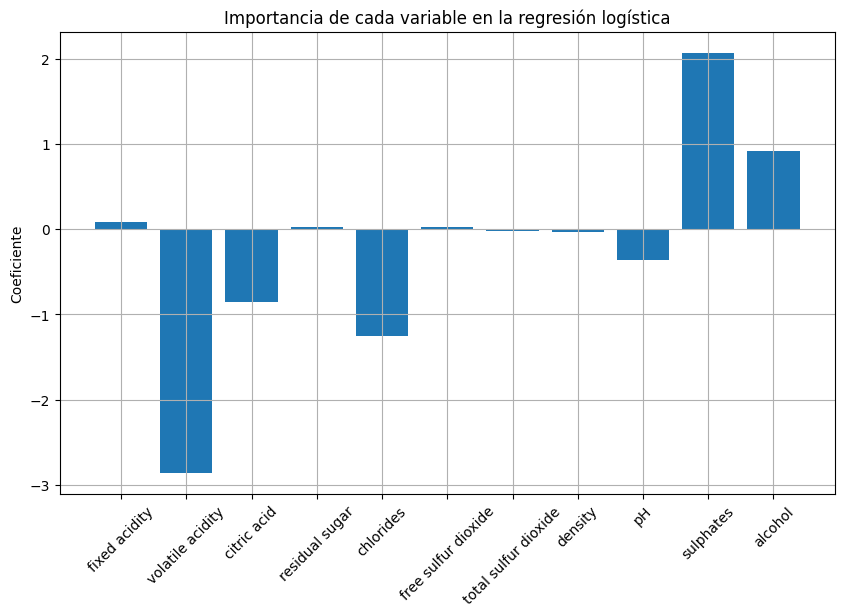

0.7498045347928068
0.73125


In [5]:
#Visualizacion de los resultados de la regresion logistica
X = vinos.drop("quality", axis=1)
y = [1 if i >= 6 else 0 for i in vinos["quality"]]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

plt.figure(figsize=(10,6))
plt.bar(X.columns, model.coef_[0])
plt.xticks(rotation=45)
plt.title("Importancia de cada variable en la regresión logística")
plt.ylabel("Coeficiente")
plt.grid(True)
plt.show()

# Calculo el accuracy en train y test
print(clf.score(x_train, y_train))
print(clf.score(x_test, y_test))

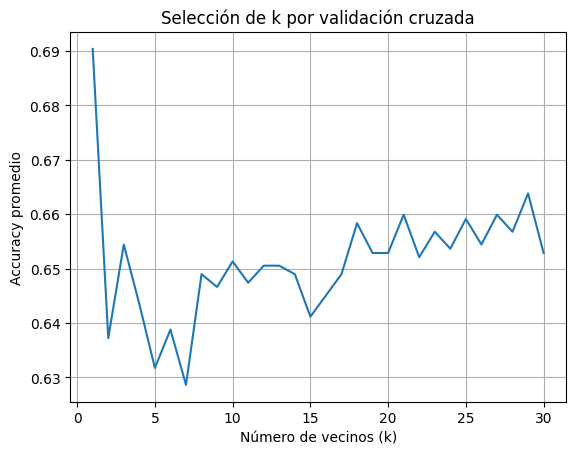

Mejor k: 1


In [6]:
#KNN

#Normalizacion  de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Candidatos de k
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

# Graficar accuracy vs k
plt.plot(k_range, cv_scores)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy promedio")
plt.title("Selección de k por validación cruzada")
plt.grid(True)
plt.show()

# Elegimos el mejor K
best_k = k_range[np.argmax(cv_scores)]
print("Mejor k:", best_k)

# Entrenamiento del modelo final
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

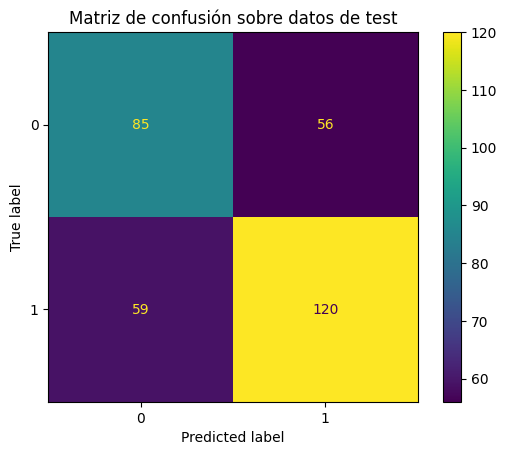

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.59      0.60      0.60       141
           1       0.68      0.67      0.68       179

    accuracy                           0.64       320
   macro avg       0.64      0.64      0.64       320
weighted avg       0.64      0.64      0.64       320



In [7]:
#Evaluacion de KNN
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot()
plt.title("Matriz de confusión sobre datos de test")
plt.show()

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))


 LDA - Accuracy: 0.581
Reporte de clasificación:
              precision    recall  f1-score   support

           4       0.33      0.18      0.24        11
           5       0.64      0.74      0.68       127
           6       0.52      0.56      0.54       129
           7       0.65      0.31      0.42        48

    accuracy                           0.58       315
   macro avg       0.54      0.45      0.47       315
weighted avg       0.58      0.58      0.57       315


 QDA - Accuracy: 0.530
Reporte de clasificación:
              precision    recall  f1-score   support

           4       0.22      0.18      0.20        11
           5       0.61      0.58      0.59       127
           6       0.48      0.53      0.50       129
           7       0.53      0.48      0.51        48

    accuracy                           0.53       315
   macro avg       0.46      0.44      0.45       315
weighted avg       0.53      0.53      0.53       315


 Naive Bayes - Accuracy: 0.53

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


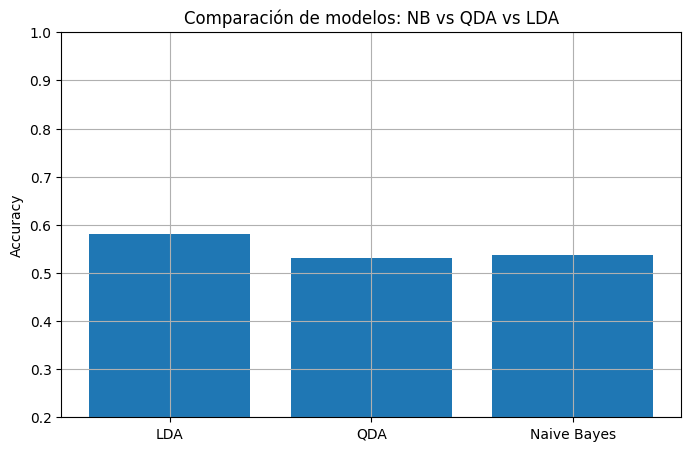

In [11]:
#QDA , NB , LDA

# Filtrar clases con al menos 30 observaciones
clases_validas = vinos["quality"].value_counts()[vinos["quality"].value_counts() >= 30].index
vinos_filtrado = vinos[vinos["quality"].isin(clases_validas)]

# Separar variables predictoras y objetivo
X = vinos_filtrado.drop("quality", axis=1)
y = vinos_filtrado["quality"]

# Dividir en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Definir modelos
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
nb = GaussianNB()

modelos = {
    "LDA": lda,
    "QDA": qda,
    "Naive Bayes": nb
}

#Entrenar, predecir y evaluar
resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(x_train, y_train)
    y_pred = modelo.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc
    print(f"\n {nombre} - Accuracy: {acc:.3f}")
    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred))

#  Comparación visual
plt.figure(figsize=(8,5))
plt.bar(resultados.keys(), resultados.values())
plt.ylabel("Accuracy")
plt.title("Comparación de modelos: NB vs QDA vs LDA")
plt.ylim(0.2, 1.0)
plt.grid(True)
plt.show()

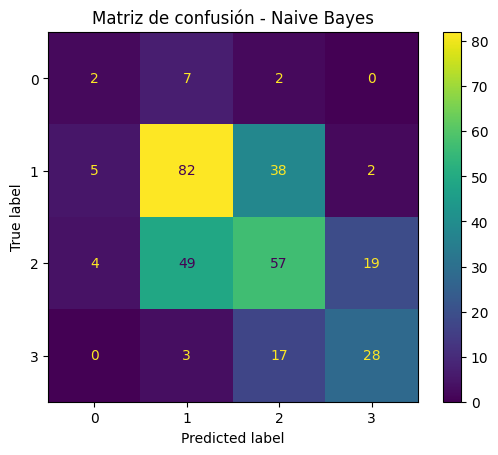

In [10]:
#NB con la matriz confusion
y_pred_nb = nb.predict(x_test)
cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb).plot()
plt.title("Matriz de confusión - Naive Bayes")
plt.show()

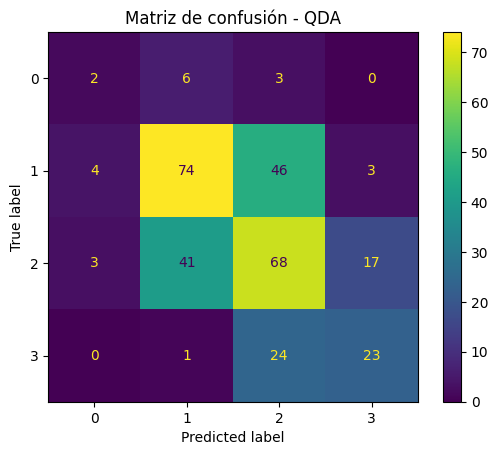

In [9]:
#QDA con la matriz confusion
y_pred_qda = qda.predict(x_test)
cm_qda = confusion_matrix(y_test, y_pred_qda)
ConfusionMatrixDisplay(cm_qda).plot()
plt.title("Matriz de confusión - QDA")
plt.show()

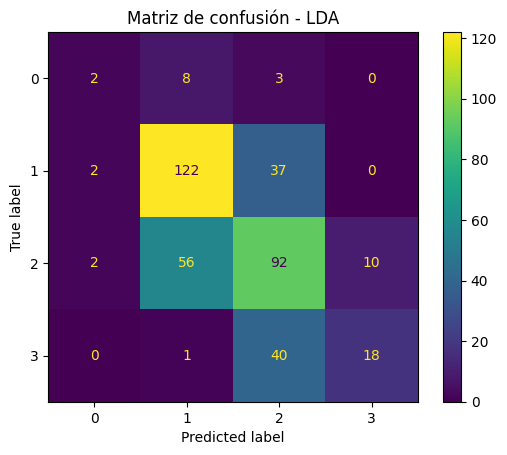

In [ ]:
#LDA con la matriz confusion
y_pred_lda = lda.predict(x_test)
cm_lda = confusion_matrix(y_test, y_pred_lda)
ConfusionMatrixDisplay(cm_lda).plot()
plt.title("Matriz de confusión - LDA")
plt.show()